In [3]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [5]:
movie_data = pd.read_csv(
    "IMDb Movies_India.csv",
    encoding="latin1"
)

movie_data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [6]:
movie_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  str    
 1   Year      14981 non-null  str    
 2   Duration  7240 non-null   str    
 3   Genre     13632 non-null  str    
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   str    
 6   Director  14984 non-null  str    
 7   Actor 1   13892 non-null  str    
 8   Actor 2   13125 non-null  str    
 9   Actor 3   12365 non-null  str    
dtypes: float64(1), str(9)
memory usage: 1.2 MB


In [7]:
print(movie_data.isnull().sum())

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [8]:
movie_data = movie_data.dropna(
    subset=["Rating"]
)

In [9]:
movie_data["Genre"] = movie_data["Genre"].fillna("Unknown")

movie_data["Director"] = movie_data["Director"].fillna("Unknown")

movie_data["Actor 1"] = movie_data["Actor 1"].fillna("Unknown")

movie_data["Actor 2"] = movie_data["Actor 2"].fillna("Unknown")

movie_data["Actor 3"] = movie_data["Actor 3"].fillna("Unknown")

In [13]:
movie_data["Year"] = pd.to_numeric(
    movie_data["Year"],
    errors="coerce"
)

movie_data["Year"] = movie_data["Year"].fillna(
    movie_data["Year"].median()
)

In [15]:
movie_data["Duration"] = movie_data["Duration"].str.replace(
    " min",
    "",
    regex=False
)

movie_data["Duration"] = pd.to_numeric(
    movie_data["Duration"],
    errors="coerce"
)

movie_data["Duration"] = movie_data["Duration"].fillna(
    movie_data["Duration"].median()
)

In [16]:
movie_data["Votes"] = movie_data["Votes"].astype(str)

movie_data["Votes"] = movie_data["Votes"].str.replace(
    ",",
    "",
    regex=False
)

movie_data["Votes"] = pd.to_numeric(
    movie_data["Votes"],
    errors="coerce"
)

movie_data["Votes"] = movie_data["Votes"].fillna(
    movie_data["Votes"].median()
)

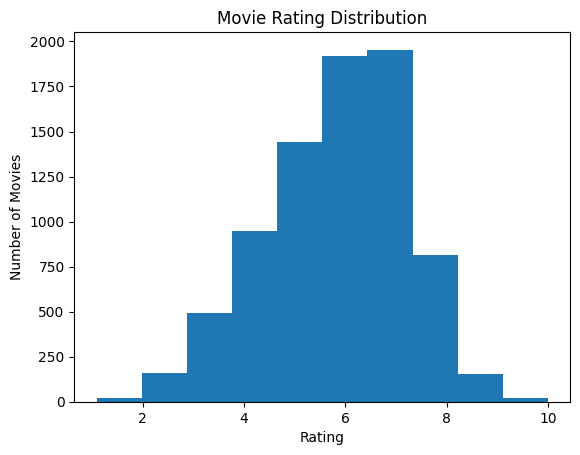

In [29]:
import matplotlib.pyplot as plt

plt.hist(movie_data["Rating"], bins=10)

plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")

plt.show()

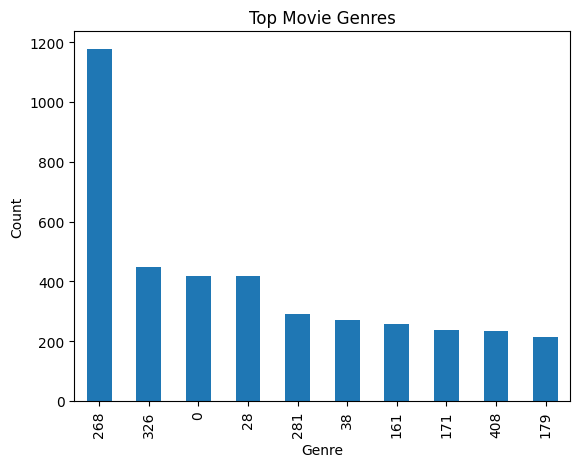

In [30]:
movie_data["Genre"].value_counts().head(10).plot(kind="bar")

plt.title("Top Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

In [17]:
label_encoder = LabelEncoder()

movie_data["Genre"] = label_encoder.fit_transform(
    movie_data["Genre"]
)

movie_data["Director"] = label_encoder.fit_transform(
    movie_data["Director"]
)

movie_data["Actor 1"] = label_encoder.fit_transform(
    movie_data["Actor 1"]
)

movie_data["Actor 2"] = label_encoder.fit_transform(
    movie_data["Actor 2"]
)

movie_data["Actor 3"] = label_encoder.fit_transform(
    movie_data["Actor 3"]
)

In [18]:
input_data = movie_data[
    [
        "Year",
        "Duration",
        "Genre",
        "Votes",
        "Director",
        "Actor 1",
        "Actor 2",
        "Actor 3"
    ]
]

output_data = movie_data["Rating"]

In [19]:
x_train, x_test, y_train, y_test = train_test_split(
    input_data,
    output_data,
    test_size=0.2,
    random_state=42
)

In [20]:
rating_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rating_model.fit(
    x_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [21]:
rating_prediction = rating_model.predict(
    x_test
)

print(rating_prediction[:10])

[4.417 5.065 4.99  5.639 5.223 6.043 5.653 6.899 5.585 5.937]


In [22]:
mae = mean_absolute_error(
    y_test,
    rating_prediction
)

print("Mean Absolute Error :", mae)

Mean Absolute Error : 0.831645202020202


In [23]:
score = r2_score(
    y_test,
    rating_prediction
)

print("R2 Score :", score)

R2 Score : 0.34972214230993715
